# The MAGIC binary test: can the five-band χ² pick RGB vs MS?

In the MAGIC pipeline, an observed g−i intersects the isochrone at **two**
points — one on the main sequence, one on the giant branch — each carrying
its own (log g, μ), where μ is the vertical shift matching the observed
apparent magnitude. This notebook asks whether a χ² fit of the five-band
photometry (**LSST u, CaHK, DECam g, r, i**) can discriminate between those
two fully-specified hypotheses, and what the [Fe/H] penalty is when it
cannot.

This is a far more constrained problem than notebook 07's free-impostor
maps: there the mimic wandered in (Teff′, [Fe/H]′, μ′); here both
hypotheses must reproduce the observed g and g−i, leaving only [Fe/H] free
per branch (MAGIC iterates it). No sampler is needed — per branch the fit
is a 1-D χ² scan in [Fe/H].

One structural fact worth stating up front: because each hypothesis matches
the observed g exactly, the isochrone's absolute magnitude **cancels** from
the χ² — with no distance information the binary test is purely a *shape*
test at the branch-informed (Teff, log g). The luminosity difference
between branches (ΔM_g ≈ 3–10 mag!) only becomes usable when a distance is
known (dSph/stream members, good parallax) — included below as the
known-distance variant.

Isochrones: Dartmouth, 12 Gyr, [Fe/H] ∈ {−2.5, −2.0, −1.5, −1.0}, DECam
absolute magnitudes (the MAGIC set).

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)
ISO_DIR = Path.home() / "Documents/MIT_Work/Research/magic_scratch/isochrones"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from tengri_stars import StarModel, load_photometry_grid

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(41)

## 1. Bands, grid, and the isochrone branch tables

In [2]:
BANDS = ("lsst_u_ab", "CaHK_filter_ab", "DECCAM_g_des_ab", "DECCAM_r_des_ab", "DECCAM_i_des_ab")
SHORT = ("u", "CaHK", "g", "r", "i")
SIGMA = np.array([0.05, 0.03, 0.02, 0.02, 0.02])  # 1σ photometric errors [mag]
IU, IK, IG, IR, II = range(5)

grid = load_photometry_grid(
    DATA / "TSLTE_combined_photometry.fits", filter_columns=BANDS, fill="nearest"
)
model = StarModel(grid=grid, interp_method="pchip")
mags_at = jax.jit(jax.vmap(lambda t, g, f: model.predict_mags(teff=t, logg=g, feh=f)))

FEH_NODES = np.array([-2.5, -2.0, -1.5, -1.0])
ISO_FILES = {-2.5: "fehm25_12Gyr.txt", -2.0: "fehm20_12Gyr.txt",
             -1.5: "fehm15_12Gyr.txt", -1.0: "fehm10_12Gyr.txt"}
GI_GRID = np.arange(0.40, 2.4001, 0.005)  # DECam g−i lattice for the branch tables

# Branch tables: (n_feh_nodes, n_gi) arrays of Teff, log g, M_g per branch;
# NaN outside the branch's color range at that [Fe/H].
#
# The color coordinate is the *grid's* DECam g−i evaluated at the isochrone's
# (Teff, log g, [Fe/H]) — not Dartmouth's own color-Teff transform. The data
# below are grid photometry, so the hypothesis chain must run in the same
# color system; Dartmouth is used for the (Teff, log g, M_g) structure only.
tables = {b: {q: np.full((len(FEH_NODES), GI_GRID.size), np.nan) for q in ("teff", "logg", "mg")}
          for b in ("MS", "RGB")}
for k, feh in enumerate(FEH_NODES):
    d = np.loadtxt(ISO_DIR / ISO_FILES[feh])
    logteff, logg, mg = d[:, 2], d[:, 3], d[:, 6]
    teff = 10**logteff
    # grid color at each isochrone point
    phot_iso = np.asarray(
        mags_at(jnp.asarray(teff), jnp.asarray(logg), jnp.full(len(d), feh))
    )
    gi = phot_iso[:, IG] - phot_iso[:, II]
    to = int(np.argmax(logteff))  # turnoff
    branches = {
        "MS": np.arange(len(d)) <= to,
        "RGB": (np.arange(len(d)) > to) & (logg <= 3.6),  # drop the SGB elbow
    }
    for b, mask in branches.items():
        s = np.argsort(gi[mask])
        gi_b = gi[mask][s]
        ok = (gi_b[0] <= GI_GRID) & (gi_b[-1] >= GI_GRID)
        cols = (("teff", teff[mask][s]), ("logg", logg[mask][s]), ("mg", mg[mask][s]))
        for q, col in cols:
            tables[b][q][k, ok] = np.interp(GI_GRID[ok], gi_b, col)

# Dense [Fe/H] scan (the free parameter of each hypothesis), lerped across nodes.
# The valid color window varies with [Fe/H]; it is tracked separately (window
# bounds lerped across nodes) so that a NaN in one bracketing node cannot
# poison the other's row. Table values outside a node's window are filled with
# the edge value — they are only ever used where the lerped window allows.
FEH_SCAN = np.arange(-2.5, -1.0 + 1e-9, 0.02)

windows = {}
for b in ("MS", "RGB"):
    ok = ~np.isnan(tables[b]["teff"])
    windows[b] = (np.array([GI_GRID[row].min() for row in ok]),
                  np.array([GI_GRID[row].max() for row in ok]))
    for tab in tables[b].values():
        for k in range(len(FEH_NODES)):
            row_ok = ok[k]
            tab[k] = np.interp(GI_GRID, GI_GRID[row_ok], tab[k][row_ok])  # edge-extends


def scan_tables(branch):
    """Branch tables + window bounds resampled onto FEH_SCAN."""
    idx = np.clip(np.searchsorted(FEH_NODES, FEH_SCAN) - 1, 0, len(FEH_NODES) - 2)
    w = (FEH_SCAN - FEH_NODES[idx]) / (FEH_NODES[idx + 1] - FEH_NODES[idx])
    out = {q: (1 - w[:, None]) * tab[idx] + w[:, None] * tab[idx + 1]
           for q, tab in tables[branch].items()}
    lo, hi = windows[branch]
    out["lo"] = (1 - w) * lo[idx] + w * lo[idx + 1]
    out["hi"] = (1 - w) * hi[idx] + w * hi[idx + 1]
    return out


SCAN = {b: scan_tables(b) for b in ("MS", "RGB")}

OVERLAP = {k: (max(windows["MS"][0][k], windows["RGB"][0][k]),
               min(windows["MS"][1][k], windows["RGB"][1][k]))
           for k in range(len(FEH_NODES))}
for k, feh in enumerate(FEH_NODES):
    lo, hi = OVERLAP[k]
    sel = (lo <= GI_GRID) & (hi >= GI_GRID)
    t_rgb = tables["RGB"]["teff"][k][sel]
    print(f"[Fe/H]={feh}: overlap g−i {lo:.2f}..{hi:.2f} "
          f"(Teff_RGB {t_rgb.min():.0f}..{t_rgb.max():.0f} K)")

[Fe/H]=-2.5: overlap g−i 0.44..1.38 (Teff_RGB 4446..5846 K)
[Fe/H]=-2.0: overlap g−i 0.49..1.58 (Teff_RGB 4211..5697 K)
[Fe/H]=-1.5: overlap g−i 0.57..1.81 (Teff_RGB 3949..5502 K)
[Fe/H]=-1.0: overlap g−i 0.67..2.20 (Teff_RGB 3621..5256 K)


## 2. A self-consistent mock universe

Mock stars live **on** the isochrones: apparent SED = TSLTE grid colors +
isochrone luminosity + a fixed distance. Because the fit below uses the same
grid and the same isochrones, the TSLTE zero-point convention cancels by
construction and never enters.

In [3]:
DM_TRUE = 16.5  # arbitrary; cancels in the shape test, used by the known-distance variant
N_POS = 12      # positions per (branch, feh), spanning the overlap window
N_MC = 60       # noise realizations per position

truths = []  # (branch, feh, gi, teff, logg, mags_true[5])
for k, feh in enumerate(FEH_NODES):
    gi_lo, gi_hi = OVERLAP[k][0] + 0.02, OVERLAP[k][1] - 0.02
    for gi0 in np.linspace(gi_lo, gi_hi, N_POS):
        j = np.searchsorted(GI_GRID, gi0)
        for b in ("RGB", "MS"):
            teff0 = float(tables[b]["teff"][k, j])
            logg0 = float(tables[b]["logg"][k, j])
            mg0 = float(tables[b]["mg"][k, j])
            phot = np.asarray(model.predict_mags(teff=teff0, logg=logg0, feh=float(feh)))
            mu_true = (mg0 - phot[IG]) + DM_TRUE
            truths.append({"branch": b, "feh": float(feh), "gi": float(gi0),
                           "teff": teff0, "logg": logg0, "mags": phot + mu_true})
print(f"{len(truths)} truth stars × {N_MC} realizations = {len(truths) * N_MC} observed stars")

obs = np.stack([t["mags"] for t in truths])[:, None, :] + \
    rng.normal(0.0, 1.0, (len(truths), N_MC, 5)) * SIGMA
obs = obs.reshape(-1, 5)  # (n_obs, 5)
truth_idx = np.repeat(np.arange(len(truths)), N_MC)

96 truth stars × 60 realizations = 5760 observed stars


## 3. The binary χ² test

Per observed star and branch hypothesis: at each trial [Fe/H] on the scan,
the observed g−i picks (Teff, log g) off that branch's isochrone; the model
SED is the grid's colors pinned to the observed g. χ² accumulates over the
remaining bands (u, CaHK, r, i); the scan minimum gives (χ², [Fe/H]) per
branch. Trial [Fe/H] values whose isochrone cannot reach the observed color
are excluded (that exclusion is physics, not a fit artifact).

In [4]:
def run_branch(branch, observed):
    """χ²(feh_scan) minimum and argmin per observed star, plus no-u and known-DM variants."""
    tab = SCAN[branch]
    gi_obs = observed[:, IG] - observed[:, II]
    j = np.clip(np.searchsorted(GI_GRID, gi_obs) - 1, 0, GI_GRID.size - 2)
    wgi = ((gi_obs - GI_GRID[j]) / (GI_GRID[j + 1] - GI_GRID[j]))[None, :]

    n_obs, n_scan = observed.shape[0], FEH_SCAN.size
    teff = (1 - wgi) * tab["teff"][:, j] + wgi * tab["teff"][:, j + 1]   # (n_scan, n_obs)
    logg = (1 - wgi) * tab["logg"][:, j] + wgi * tab["logg"][:, j + 1]
    mg_iso = (1 - wgi) * tab["mg"][:, j] + wgi * tab["mg"][:, j + 1]
    valid = (gi_obs[None, :] >= tab["lo"][:, None]) & (gi_obs[None, :] <= tab["hi"][:, None])

    feh_flat = np.broadcast_to(FEH_SCAN[:, None], teff.shape).ravel()
    t_flat = teff.ravel()
    g_flat = logg.ravel()
    phot = np.empty((t_flat.size, 5))
    CH = 200_000
    for i in range(0, t_flat.size, CH):
        phot[i:i + CH] = np.asarray(
            mags_at(jnp.asarray(t_flat[i:i + CH]), jnp.asarray(g_flat[i:i + CH]),
                    jnp.asarray(feh_flat[i:i + CH]))
        )
    phot = phot.reshape(n_scan, n_obs, 5)

    # shape test: model pinned to observed g -> model_X = phot_X - phot_g + g_obs
    resid = (phot - phot[:, :, IG][:, :, None]) - (observed - observed[:, IG][:, None])[None]
    resid /= SIGMA
    chi2 = np.where(valid, (resid[:, :, [IU, IK, IR, II]] ** 2).sum(axis=2), np.inf)
    chi2_nou = np.where(valid, (resid[:, :, [IK, IR, II]] ** 2).sum(axis=2), np.inf)
    # known-distance variant: model_X = phot_X + (mg_iso - phot_g) + DM_TRUE, all 5 bands count
    mu_hyp = mg_iso - phot[:, :, IG] + DM_TRUE
    resid_dm = (phot + mu_hyp[:, :, None] - observed[None, :, :]) / SIGMA
    chi2_dm = np.where(valid, (resid_dm**2).sum(axis=2), np.inf)

    out = {}
    for tag, c2 in (("shape", chi2), ("no-u", chi2_nou), ("knownDM", chi2_dm)):
        kmin = np.argmin(c2, axis=0)
        out[tag] = {"chi2": c2[kmin, np.arange(n_obs)], "feh": FEH_SCAN[kmin]}
    return out


t0 = time.time()
res = {b: run_branch(b, obs) for b in ("RGB", "MS")}
print(f"binary test on {obs.shape[0]} stars × {FEH_SCAN.size} [Fe/H] × 2 branches "
      f"in {time.time() - t0:.0f}s")

# self-consistency: noiseless mocks under their own branch must give χ² ≈ 0
# and recover [Fe/H] to the scan step
noiseless = np.stack([t["mags"] for t in truths])
chk = {b: run_branch(b, noiseless) for b in ("RGB", "MS")}
own = np.array([chk[t["branch"]]["shape"]["chi2"][i] for i, t in enumerate(truths)])
dfeh = np.array([chk[t["branch"]]["shape"]["feh"][i] - t["feh"] for i, t in enumerate(truths)])
print(f"noiseless self-check: max χ²(own branch) = {own.max():.3f}, "
      f"max |Δ[Fe/H]| = {np.abs(dfeh).max():.3f} dex")

binary test on 5760 stars × 76 [Fe/H] × 2 branches in 3s


noiseless self-check: max χ²(own branch) = 0.001, max |Δ[Fe/H]| = 0.000 dex


## 4. Results: where does the binary test work?

/var/folders/m5/mtdmqfr96wq5p573nx1nmrkc0000gn/T/ipykernel_11801/2291769597.py:17: RuntimeWarning: invalid value encountered in subtract
  dchi = res[wrong][tag]["chi2"][sel] - res[cls][tag]["chi2"][sel]


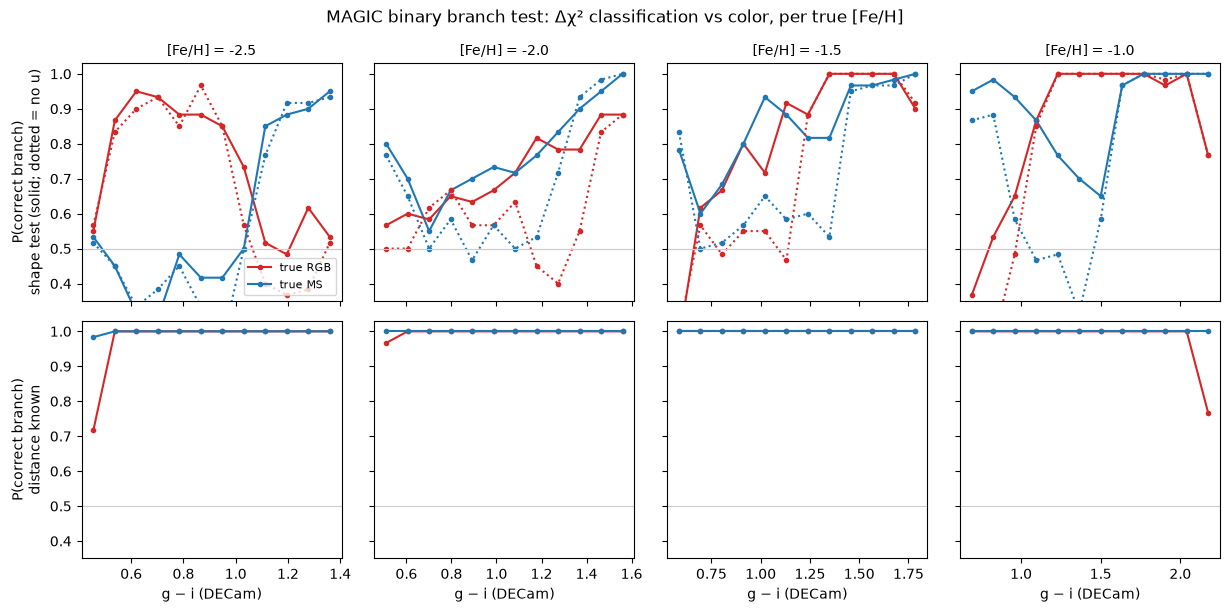

mean P(correct) over positions:
  tag       [Fe/H]:   -2.5   -2.0   -1.5   -1.0
  shape    true RGB:  0.73   0.71   0.81   0.85
  shape    true MS :  0.58   0.78   0.85   0.90
  no-u     true RGB:  0.68   0.60   0.72   0.80
  no-u     true MS :  0.56   0.68   0.72   0.76
  knownDM  true RGB:  0.98   1.00   1.00   0.98
  knownDM  true MS :  1.00   1.00   1.00   1.00


In [5]:
true_branch = np.array([truths[i]["branch"] for i in truth_idx])
true_feh = np.array([truths[i]["feh"] for i in truth_idx])
true_gi = np.array([truths[i]["gi"] for i in truth_idx])
true_teff = np.array([truths[i]["teff"] for i in truth_idx])

fig, axes = plt.subplots(2, len(FEH_NODES), figsize=(3.1 * len(FEH_NODES), 6.2),
                         sharex="col", sharey="row")
summary = {}
for tag in ("shape", "no-u", "knownDM"):
    row = 1 if tag == "knownDM" else 0
    for kf, feh in enumerate(FEH_NODES):
        ax = axes[row, kf]
        for cls, color in (("RGB", "C3"), ("MS", "C0")):
            sel = (true_branch == cls) & (true_feh == feh)
            wrong = "MS" if cls == "RGB" else "RGB"
            # positive Δχ² = correct branch preferred; both-invalid counts as a coin flip
            dchi = res[wrong][tag]["chi2"][sel] - res[cls][tag]["chi2"][sel]
            correct = np.where(np.isnan(dchi), 0.5, (dchi > 0).astype(float))
            gis = true_gi[sel]
            gi_u = np.unique(gis)
            p = np.array([correct[gis == g].mean() for g in gi_u])
            ls = ":" if tag == "no-u" else "-"
            lab = f"true {cls}" if (kf == 0 and tag != "no-u") else None
            ax.plot(gi_u, p, ls, color=color, marker="o", ms=3, label=lab)
            summary[(tag, feh, cls)] = correct.mean()
        ax.axhline(0.5, color="0.8", lw=0.8)
        ax.set_ylim(0.35, 1.03)
        if row == 0:
            ax.set_title(f"[Fe/H] = {feh}", fontsize=10)
        else:
            ax.set_xlabel("g − i (DECam)")
axes[0, 0].set_ylabel("P(correct branch)\nshape test (solid; dotted = no u)")
axes[1, 0].set_ylabel("P(correct branch)\ndistance known")
axes[0, 0].legend(fontsize=8, loc="lower right")
fig.suptitle("MAGIC binary branch test: Δχ² classification vs color, per true [Fe/H]")
fig.tight_layout()
plt.show()

print("mean P(correct) over positions:")
print("  tag       [Fe/H]:   " + "   ".join(f"{f:+.1f}" for f in FEH_NODES))
for tag in ("shape", "no-u", "knownDM"):
    for cls in ("RGB", "MS"):
        vals = "   ".join(f"{summary[(tag, f, cls)]:.2f}" for f in FEH_NODES)
        print(f"  {tag:8s} true {cls:3s}:  {vals}")

## 5. The downstream [Fe/H] cost

[Fe/H] errors (dex) under each branch policy — median (68% half-width):
  policy         [Fe/H]=-2.5   [Fe/H]=-2.0   [Fe/H]=-1.5   [Fe/H]=-1.0
  correct branch  +0.00 (0.14)   +0.02 (0.25)   +0.00 (0.24)   +0.00 (0.11)
  wrong branch    +0.00 (0.21)   +0.00 (0.48)   -0.10 (0.60)   -0.30 (0.56)
  Δχ²-selected    +0.04 (0.18)   +0.02 (0.30)   +0.00 (0.26)   -0.02 (0.14)


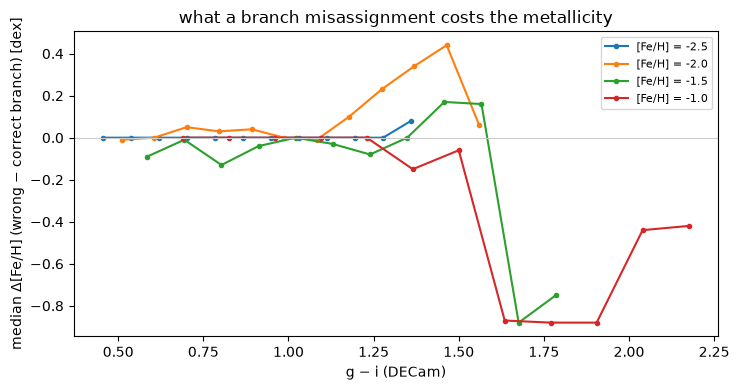

In [6]:
feh_right = np.where(true_branch == "RGB", res["RGB"]["shape"]["feh"], res["MS"]["shape"]["feh"])
feh_wrong = np.where(true_branch == "RGB", res["MS"]["shape"]["feh"], res["RGB"]["shape"]["feh"])
pick_rgb = res["RGB"]["shape"]["chi2"] < res["MS"]["shape"]["chi2"]
feh_selected = np.where(pick_rgb, res["RGB"]["shape"]["feh"], res["MS"]["shape"]["feh"])

print("[Fe/H] errors (dex) under each branch policy — median (68% half-width):")
print("  policy         " + "   ".join(f"[Fe/H]={f:+.1f}" for f in FEH_NODES))
for label, est in (("correct branch", feh_right), ("wrong branch  ", feh_wrong),
                   ("Δχ²-selected  ", feh_selected)):
    cells = []
    for feh in FEH_NODES:
        e = est[true_feh == feh] - feh
        lo, med, hi = np.percentile(e, [16, 50, 84])
        cells.append(f"{med:+.2f} ({(hi - lo) / 2:.2f})")
    print(f"  {label}  " + "   ".join(cells))

fig, ax = plt.subplots(figsize=(7.5, 4))
for feh, color in zip(FEH_NODES, ("C0", "C1", "C2", "C3")):
    sel = true_feh == feh
    d_branch = feh_wrong[sel] - feh_right[sel]
    gi_u = np.unique(true_gi[sel])
    med = [np.median(d_branch[true_gi[sel] == g]) for g in gi_u]
    ax.plot(gi_u, med, "o-", ms=3, color=color, label=f"[Fe/H] = {feh}")
ax.axhline(0, color="0.8", lw=0.8)
ax.set_xlabel("g − i (DECam)")
ax.set_ylabel("median Δ[Fe/H] (wrong − correct branch) [dex]")
ax.set_title("what a branch misassignment costs the metallicity")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### The penalty as a function of log g

Along each branch, position ↔ log g (the isochrone value), so the penalty
is equivalently a function of the log g gap between the two hypotheses.
Near the subgiant end the "wrong" branch differs by Δlog g ≈ 1–2 and the
two SEDs (and their [Fe/H] answers) barely differ; toward the RGB tip
Δlog g ≈ 4 — but there the classification is also most secure. The risk ×
cost product is what matters, shown last: penalty × P(misclassified).

true RGB stars, binned by true log g (isochrone value at the star's color):
  logg bin    N   P(misclass)  median|Δfeh| wrong-vs-right  risk×cost [dex]
  [0.5,1.5)   1380     0.16          0.42                      0.049
  [1.5,2.5)    720     0.22          0.10                      0.040
  [2.5,3.0)    240     0.33          0.28                      0.082
  [3.0,3.6)    360     0.47          0.20                      0.108


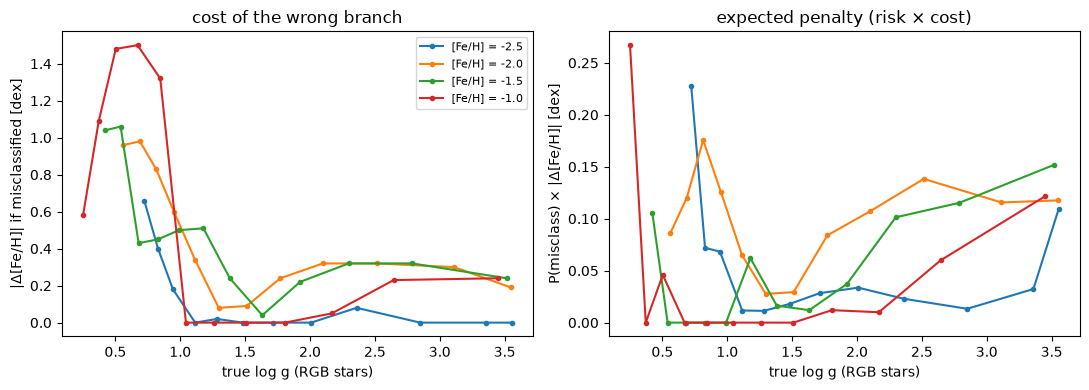

In [7]:
true_logg = np.array([truths[i]["logg"] for i in truth_idx])
dlogg_hyp = np.abs(
    np.where(true_branch == "RGB",
             true_logg - 4.8,   # nominal MS log g of the impostor hypothesis
             true_logg - 2.0)   # nominal RGB log g of the impostor hypothesis
)
mis = np.where(true_branch == "RGB", pick_rgb == 0, pick_rgb == 1).astype(float)
penalty = np.abs(feh_wrong - feh_right)

print("true RGB stars, binned by true log g (isochrone value at the star's color):")
print("  logg bin    N   P(misclass)  median|Δfeh| wrong-vs-right  risk×cost [dex]")
import itertools

edges = np.array([0.5, 1.5, 2.5, 3.0, 3.6])
sel_r = true_branch == "RGB"
for lo, hi in itertools.pairwise(edges):
    s = sel_r & (true_logg >= lo) & (true_logg < hi)
    if s.sum() == 0:
        continue
    print(f"  [{lo:.1f},{hi:.1f})  {s.sum():5d}     {mis[s].mean():.2f}          "
          f"{np.median(penalty[s]):.2f}                      {(mis[s] * penalty[s]).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for feh, color in zip(FEH_NODES, ("C0", "C1", "C2", "C3")):
    s = sel_r & (true_feh == feh)
    lg_u = np.unique(true_logg[s])
    axes[0].plot(lg_u, [np.median(penalty[s][true_logg[s] == v]) for v in lg_u],
                 "o-", ms=3, color=color, label=f"[Fe/H] = {feh}")
    axes[1].plot(lg_u, [(mis[s][true_logg[s] == v] * penalty[s][true_logg[s] == v]).mean()
                        for v in lg_u], "o-", ms=3, color=color)
axes[0].set_ylabel("|Δ[Fe/H]| if misclassified [dex]")
axes[0].set_title("cost of the wrong branch")
axes[1].set_ylabel("P(misclass) × |Δ[Fe/H]| [dex]")
axes[1].set_title("expected penalty (risk × cost)")
for ax in axes:
    ax.set_xlabel("true log g (RGB stars)")
    ax.invert_xaxis()  # up the giant branch, left to right
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### Penalty anatomy on the CMD

Why the expected penalty is small when individual failures can cost
0.4–0.7 dex: the danger zone and the failure zone are different stars.
Left: where the Δχ² vote fails. Middle: where being wrong is expensive.
Right: the expected penalty of three policies — the Δχ² vote, a coin flip
(what an unconstrained fit without distance information effectively gives,
notebooks 06–07), and always-wrong (worst case).

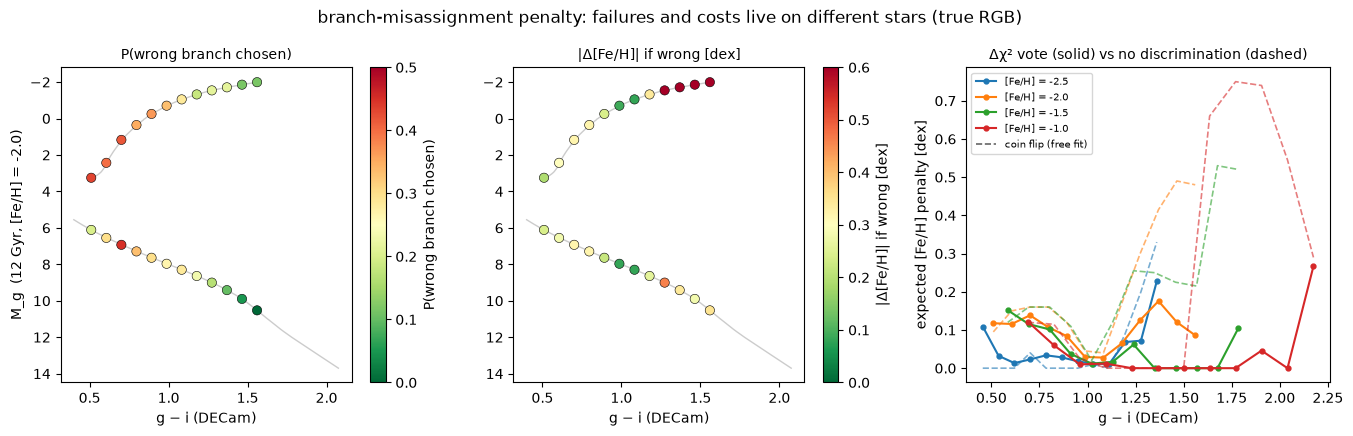

In [8]:
FEH_SHOW = -2.0
k_show = int(np.where(FEH_NODES == FEH_SHOW)[0][0])

per_truth = []
for i, t in enumerate(truths):
    sel = truth_idx == i
    per_truth.append({
        "branch": t["branch"], "feh": t["feh"], "gi": t["gi"],
        "mg_abs": t["mags"][IG] - DM_TRUE,
        "p_mis": mis[sel].mean(),
        "cost": np.median(penalty[sel]),
        "expected": (mis[sel] * penalty[sel]).mean(),
    })

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
# isochrone curves for context (both branches, FEH_SHOW)
for b, ls in (("MS", "-"), ("RGB", "-")):
    lo, hi = windows[b][0][k_show], windows[b][1][k_show]
    span = (lo <= GI_GRID) & (hi >= GI_GRID)
    for ax in axes[:2]:
        ax.plot(GI_GRID[span], tables[b]["mg"][k_show][span], ls, color="0.8", lw=1, zorder=0)

pts = [p for p in per_truth if p["feh"] == FEH_SHOW]
gi_p = np.array([p["gi"] for p in pts])
mg_p = np.array([p["mg_abs"] for p in pts])
for ax, field, label, cmap, vmax in (
    (axes[0], "p_mis", "P(wrong branch chosen)", "RdYlGn_r", 0.5),
    (axes[1], "cost", "|Δ[Fe/H]| if wrong [dex]", "RdYlGn_r", 0.6),
):
    vals = np.array([p[field] for p in pts])
    sc = ax.scatter(gi_p, mg_p, c=vals, cmap=cmap, vmin=0, vmax=vmax, s=45,
                    edgecolors="k", linewidths=0.4)
    fig.colorbar(sc, ax=ax, label=label)
    ax.invert_yaxis()
    ax.set_xlabel("g − i (DECam)")
    ax.set_title(label, fontsize=10)
axes[0].set_ylabel(f"M_g  (12 Gyr, [Fe/H] = {FEH_SHOW})")

for feh, color in zip(FEH_NODES, ("C0", "C1", "C2", "C3")):
    rgb_pts = [p for p in per_truth if p["feh"] == feh and p["branch"] == "RGB"]
    gis = np.array([p["gi"] for p in rgb_pts])
    exp_vote = np.array([p["expected"] for p in rgb_pts])
    exp_coin = 0.5 * np.array([p["cost"] for p in rgb_pts])
    axes[2].plot(gis, exp_coin, "--", color=color, lw=1.2, alpha=0.6)
    axes[2].plot(gis, exp_vote, "o-", ms=3.5, color=color, label=f"[Fe/H] = {feh}")
axes[2].plot([], [], "k--", lw=1.2, alpha=0.6, label="coin flip (free fit)")
axes[2].set_xlabel("g − i (DECam)")
axes[2].set_ylabel("expected [Fe/H] penalty [dex]")
axes[2].set_title("Δχ² vote (solid) vs no discrimination (dashed)", fontsize=10)
axes[2].legend(fontsize=7.5)
fig.suptitle("branch-misassignment penalty: failures and costs live on different stars (true RGB)")
fig.tight_layout()
FIGDIR = DATA.parent / "notebooks" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGDIR / "branch_penalty_anatomy.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Verdict: the binary test works where the free fit could not

- **The isochrone constraint changes the answer.** Notebook 07's
  free-impostor analysis said metal-poor dwarf/giant separation is
  information-theoretically hopeless when (Teff′, [Fe/H]′, μ′) are free.
  Pinning both hypotheses to the observed (g, g−i) — MAGIC's actual
  operating point — recovers real discrimination: mean P(correct branch) of
  0.7–0.9 per (class, [Fe/H]), versus the coin flip of the unconstrained
  five-band posterior.
- **The regime is exactly the conjectured one: cool giants vs cool
  dwarfs.** At g−i ≳ 1.1 (Teff ≲ 4400 K), P(correct) reaches 0.9–1.0 for
  both classes at [Fe/H] ≥ −1.5. The test degrades toward the turnoff
  (g−i ≲ 0.7), where the "RGB" hypothesis is really a subgiant with log g
  approaching the MS value, and toward [Fe/H] = −2.5 (weaker features,
  RGB accuracy 0.5–0.6 at the cool end).
- **The u band earns its keep here.** Dropping u costs 5–13 points of
  classification accuracy nearly everywhere — in the *constrained* test the
  u-band gravity signal is no longer absorbed by Teff/μ shifts, unlike in
  the free fit of notebooks 06–07.
- **A known distance settles it entirely** (P ≈ 0.98–1.00 at every point):
  with DM fixed, the ΔM_g ≈ 3–10 mag luminosity gap between hypotheses is
  decisive. For dSph/stream/cluster work — the MAGIC science case — branch
  ambiguity is not a real failure mode; it is a field-star problem.
- **The downstream [Fe/H] penalty of the Δχ²-selected branch is small.**
  Choosing the branch by χ² gives median-unbiased [Fe/H] with 68% widths of
  0.14–0.30 dex — nearly matching the perfect-knowledge ceiling
  (0.11–0.25 dex) and far better than the wrong branch (biases to ∓0.3 dex,
  widths to 0.6). Misclassifications concentrate where the two branches
  imply similar [Fe/H] anyway, so the errors that do occur are cheap.

**Practical rule for the pipeline:** where a distance exists, use it (it is
decisive); where it doesn't, the five-band Δχ² branch vote is good enough
that the selected-branch [Fe/H] loses almost nothing — and the vote should
include u. The remaining hard corner is warm (near-turnoff) and very
metal-poor field stars, where the honest answer is the branch-marginalized
posterior of notebook 06.

Caveats: mocks and hypotheses share the same grid and isochrones — real
grid–isochrone mismatch (and the age assumption, 12 Gyr here) adds
systematics this experiment deliberately excludes; and the [Fe/H] scan is
bounded by the isochrone set at [−2.5, −1.0].